In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix ,classification_report 
import pickle


In [4]:
import os 
os.listdir(r"C:\Users\Admin\OneDrive\Documents\Pandas")
df= pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.drop(columns=["customerID"], inplace=True)

for col in df.columns:
    print (col,df[col].unique())
    print("-"*50)
df["TotalCharges"]= df["TotalCharges"].replace({" ": "0.0"})
df["TotalCharges"]= df["TotalCharges"].astype(float)
df.info()
print(df["Churn"].value_counts())
df.head(3)

df["TotalCharges"]= df["TotalCharges"].replace({" ": "0.0"})
df["TotalCharges"]= df["TotalCharges"].astype(float)
df.info()
print(df["Churn"].value_counts())

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
-------

In [6]:
#Exploratory Data Analysis (EDA)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
def plot_histogram(df,column_name):
    plt.figure(figsize=(5,3))
    sns.histplot(df[column_name],kde=True)
    plt.title(f"distribution of [column_name]")

    col_mean=df[column_name].mean()
    col_median=df[column_name].median()

    plt.axvline(col_mean,color="red",linestyle="--",label="mean")
    plt.axvline(col_median,color="yellow",linestyle="dotted",label="median")

    plt.legend()
    plt.show()

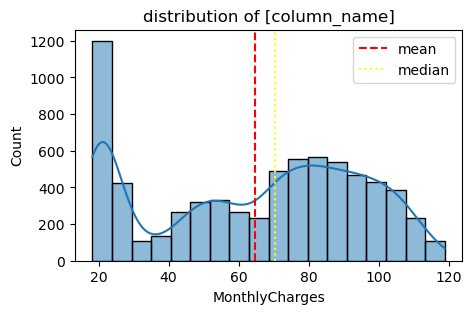

In [8]:
plot_histogram(df,"MonthlyCharges")

In [9]:
# Box plot for numeric feature
def plot_boxplot(df,column_name):
    plt.figure(figsize=(5,3))
    sns.boxplot(y=df[column_name])
    plt.title(f"box plot of [column_name]")
    plt.ylabel(column_name)
    plt.show()

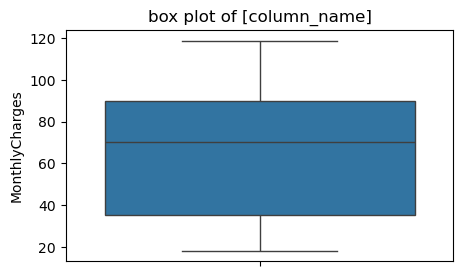

In [8]:
plot_boxplot(df,"MonthlyCharges")

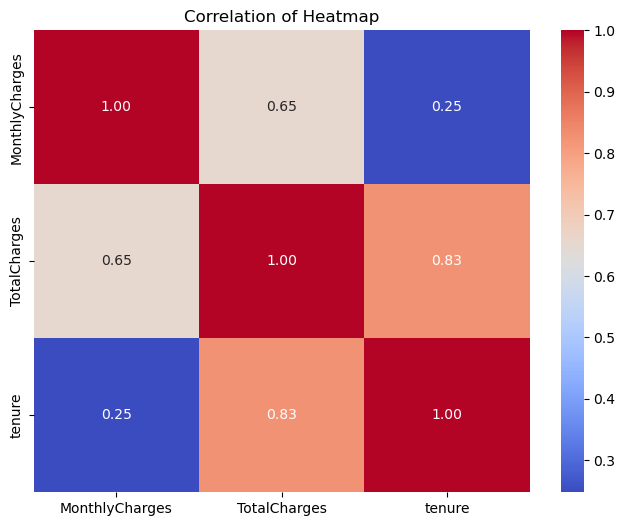

In [10]:
#Heat map - matrix
plt.figure(figsize=(8,6))
sns.heatmap(df[["MonthlyCharges","TotalCharges","tenure"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Heatmap")
plt.show()

In [ ]:
#understanding the distribution of  categorical feature analysis
#countplot for categorical columns
object_cols=df.select_dtypes(include="object").columns.to_list()
object_cols=["SeniorCitizen"] + object_cols
for col in object_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"count plot of {col}")
    plt.show()


In [12]:
#4. DATA Preprocessing 
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [15]:
# #Label encoding of target column 
df["Churn"]=df["Churn"].replace({"Yes":1, "No":0})

In [16]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [17]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [18]:
# LabelEncoding of all categorical features
# Identifying column with object data type
object_columns =df.select_dtypes(include="object").columns
print(object_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [19]:
#initilize a dictioinary to save the encoders
encoders={ }
# Apply label encoding and store the encoder
for column in object_columns:

    label_encoder=LabelEncoder()
    df[column]=label_encoder.fit_transform(df[column])
    encoders[column]=label_encoder
#save the encoder to pickel file
with open("encoders.pkl","wb") as f:
    pickle.dump(encoders,f)


In [20]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [21]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


In [23]:
#splitting the feature and target
X= df.drop(columns=["Churn"])
y=df["Churn"]
print(y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


In [24]:
# split training and test data
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size=0.2 , random_state=42)
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


In [25]:
#Synthetic Minority Oversampling Technique (SMOTE)
smote=SMOTE(random_state=42)

In [29]:
#Oversample it
X_train_smote , y_train_smote = smote.fit_resample(X_train, y_train)
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


In [32]:
#5.Model Training
#dictionary of model
models={
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":XGBClassifier(random_state=42)
}
#Dictionary to store cross validation(CV) results
cv_scores= {}
#Perforem 5-fold cross validation for each model
for model_name , model in models.items():
    print("Training {model_name} with default parameters ")
    scores= cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring ="accuracy")
    cv_scores[model_name]=scores
    print(f"[model_name] cross validation accuracy:{np.mean(scores):.2f}")
    print("-"*50)
cv_scores


Training {model_name} with default parameters 
[model_name] cross validation accuracy:0.78
--------------------------------------------------
Training {model_name} with default parameters 
[model_name] cross validation accuracy:0.84
--------------------------------------------------
Training {model_name} with default parameters 
[model_name] cross validation accuracy:0.83
--------------------------------------------------


{'Decision Tree': array([0.68297101, 0.71601208, 0.81993958, 0.83564955, 0.83746224]),
 'Random Forest': array([0.72826087, 0.7734139 , 0.90332326, 0.89969789, 0.8978852 ]),
 'XGBoost': array([0.71135266, 0.74864048, 0.91178248, 0.88640483, 0.91117825])}

In [37]:
# train the random forest model(Highest accuracy) with default parameters then find the final data accuracy
rfc=RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote, y_train_smote) 


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
#6.Model Evaluation 
#Evaluate on test data
y_test_pred= rfc.predict(X_test)
print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Accuracy Score:
 0.7771469127040455
Confusion Matrix:
 [[879 157]
 [157 216]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [41]:
#save the trained model as pickle file 
with open("Customer_01Churn_model.pkl","wb") as f:
    pickle.dump(rfc,f)
model_data= {"model":rfc , "features_names":X.columns.tolist()}

In [52]:
#7. Load the saved model and build a predictive system
#load the saved model
with open("Customer_01Churn_model.pkl","rb") as f:
    model_data= pickle.load(f)
print(model_data)


RandomForestClassifier(random_state=42)


In [101]:
input_Amar = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'DSL',
    'OnlineSecurity': 'Yes',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Mailed check',
    'MonthlyCharges': 53.85,
    'TotalCharges': 108.15
}

def predict_churn(input_dict):

    input_df = pd.DataFrame([input_dict])

    with open("encoders.pkl","rb") as f:
        encoders = pickle.load(f)

    for column, encoder in encoders.items():
        input_df[column] = encoder.transform(input_df[column])

    prediction = model_data.predict(input_df)
    probability = model_data.predict_proba(input_df)

    result = "Churn" if prediction[0] == 1 else "No Churn"

    print("Prediction:", result)
    print("Probability:", probability)

predict_churn(input_Amar)

Prediction: Churn
Probability: [[0.18 0.82]]


In [102]:
input_data2 = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}
predict_churn(input_data2)

Prediction: No Churn
Probability: [[0.79 0.21]]
